### Credit Card Fraud Detection

For this new example, let's use the "Credit Card Fraud Detection" dataset from Kaggle. This dataset is commonly used for classification problems and contains transaction data that can help detect fraudulent activity. We'll use K-Nearest Neighbors (KNN) to predict whether a transaction is fraudulent or not.

Here’s a step-by-step example of how to implement KNN, find the optimal K, and plot the error rate using this dataset.

Dataset Link:

You can download the dataset from Kaggle: Credit Card Fraud Detection

Steps to Implement:

Download the dataset and load it into your Python environment.

Preprocess the data (handling missing values, scaling features).

Implement KNN to find the optimal K.

Evaluate the model using cross-validation and error rate plots.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Step 1: Load the dataset
# Assuming you downloaded the dataset and placed it in the correct directory
df = pd.read_csv("creditcard.csv")

### Preprocess the Data:

Feature Selection: Choose relevant features such as loan_amount, interest_rate, annual_income, debt_to_income, etc.

Target Variable: The loan_status column indicates whether a loan is fully paid or charged off. Convert this into a binary variable where, for example, 'Fully Paid' = 0 and 'Charged Off' = 1.

Handle Missing Values: Check for and address any missing values in the dataset.

Standardization: Use StandardScaler from sklearn.preprocessing to standardize the numerical features.

### Implement the KNN Model:

Split the data into training and testing sets using train_test_split.

Initialize and train the KNN classifier from sklearn.neighbors.

Evaluate the model's performance using metrics like accuracy, confusion matrix, and classification report.

In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


#### Content
The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

In [13]:
# Step 2: Preprocess the data
# Drop the 'Time' feature as it's not relevant
df = df.drop('Time',  axis=1)

# Separate features and target variable
X = df.iloc[:, :3]  # Features
y = df['Class']  # Target variable (1 = fraud, 0 = not fraud)

# Normalize the features (important for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 4: Find the optimal K using cross-validation
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)  # 5-fold cross-validation
    cv_scores.append(np.mean(scores))  # Average accuracy for each K

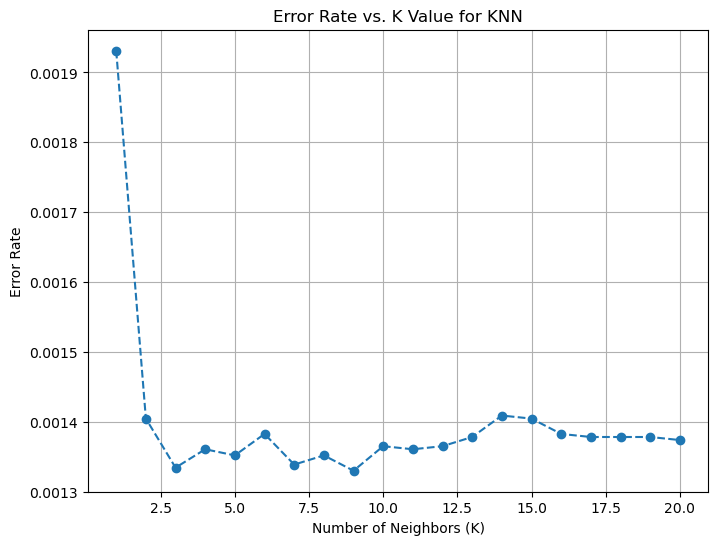

In [14]:
# Step 5: Plot the error rate for different K values
error_rates = [1 - score for score in cv_scores]  # Error rate = 1 - accuracy
plt.figure(figsize=(8, 6))
plt.plot(k_values, error_rates, marker='o', linestyle='--')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate")
plt.title("Error Rate vs. K Value for KNN")
plt.grid(True)
plt.show()

In [15]:
# Step 6: Find the optimal K (K with the minimum error rate)
optimal_k = k_values[np.argmin(error_rates)]
print(f"The optimal value of K is: {optimal_k}")

The optimal value of K is: 9


In [16]:
# Step 7: Train the KNN model with the optimal K
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9)

In [17]:
# Step 8: Make predictions and evaluate the model
y_pred = knn_optimal.predict(X_test)

In [24]:
# Step 9: Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(report)

Accuracy: 1.00
Confusion Matrix:
[[56852    12]
 [   67    31]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.32      0.44        98

    accuracy                           1.00     56962
   macro avg       0.86      0.66      0.72     56962
weighted avg       1.00      1.00      1.00     56962



Explanation of Code:

Loading the Data:

The creditcard.csv dataset is loaded into a pandas DataFrame using pd.read_csv("path_to_your_file.csv").

Preprocessing:

The Time feature is dropped because it’s not necessary for the prediction. We then separate the features (X) and target variable (y), where y is the binary classification (fraud or not fraud).
Scaling the Features:

Since KNN is sensitive to the scale of the features, we use StandardScaler to scale the features to have a mean of 0 and a standard deviation of 1.

Splitting the Data:

The dataset is split into training and test sets (80% training, 20% testing) using train_test_split.

Finding the Optimal K:

We iterate over K values from 1 to 20 and use cross-validation (cross_val_score) to calculate the accuracy for each value of K. The average accuracy score for each K is stored in cv_scores.

Plotting the Error Rate:

We compute the error rate for each K as 1 - accuracy and plot it against K values to identify the optimal K value (the one with the lowest error rate).

Training the Model:

After identifying the optimal K, we train the KNN classifier with the chosen K value on the training set.

Evaluation:

We evaluate the model by calculating the accuracy, confusion matrix, and classification report, which provides precision, recall, and F1-score.

Expected Output:

Plot: A graph showing how the error rate changes with different values of K.

Optimal K: The K value that gives the minimum error rate.

Confusion Matrix: This matrix will help you see the number of true positives, true negatives, false positives, and false negatives.

Classification Report: This report will provide additional metrics like precision, recall, and F1-score for better model evaluation.

Key Notes:

Imbalanced Dataset: The dataset is imbalanced (fraudulent transactions are much less than non-fraudulent). You might want to try balancing techniques like oversampling or undersampling for better performance.

KNN Tuning: In this example, we only tune K. However, you can also tune other parameters of KNN, such as the distance metric (metric parameter) or weights (weights parameter).

Summary:

This example walks you through the complete process of using KNN for fraud detection on a credit card transaction dataset, from finding the optimal number of neighbors (K) to evaluating the model's performance. You can easily extend this by incorporating more advanced techniques like cross-validation, feature engineering, and hyperparameter tuning to further improve the model.